# ML Pipeline Baseline — Replication & Evaluation Analysis

This notebook has two goals:

1. **Faithful replication** of the original `RF_Fingerprint.py` pipeline (SVM + ANOVA feature selection),
   reproducing the reported ~0.97 ADR result.

2. **Progressive correction** of three evaluation biases identified in the original methodology,
   isolating the contribution of each bias to the reported performance inflation.

## The three biases

| # | Bias | Location in original code |
|---|------|--------------------------|
| 1 | `SelectKBest` fitted on full dataset before fold split — **data leakage** | `select_features(X_auth, y_auth, k)` called before `skf.split()` |
| 2 | Break on first (k, fold) passing threshold — **lucky-fold selection** | `if auth_tvr >= 0.95 ... break` inside fold loop |
| 3 | k swept from 1 to 505 — **test-set model selection** | `for n_features_to_select in range(1, X_auth.shape[1]+1)` |

## Sections
1. Setup
2. Original pipeline (faithful replication)
3. Bias analysis — where and why each bias inflates results
4. Fix 1 — feature selection inside fold
5. Fix 1+2 — average all folds, no threshold break
6. Fix 1+2+3 — fixed k, no sweep
7. Comparison
8. Extra — corrected pipeline on windowed data

## Summary

**Purpose:** Replicate the original SVM pipeline (`RF_Fingerprint.py`) and expose three independent evaluation biases that inflate all reported metrics.

**Findings:**
- Bias 1 — ANOVA feature selection runs on the full dataset (train + test), leaking test-set statistics into the feature space.
- Bias 2 — The CV loop exits at the first fold that hits the target threshold, reporting the *luckiest* fold rather than the average.
- Bias 3 — The number of ANOVA features $k$ is selected by maximising Rogue TVR *on the test fold*, then evaluated on that same fold.

Removing all three biases drops Mean ADR from **0.973 → 0.458**. All biases are independent and compound.

**Prerequisites:** Run `00_setup.ipynb` first to build the FV caches. The honest DL comparison is in `02_dl_honest.ipynb`.

## Abbreviation Legend

| Abbreviation | Full name | Notes |
|---|---|---|
| PLA | Physical Layer Authentication | Device identity verification via RF hardware fingerprints |
| RF-DNA | Radio Frequency Distinct Native Attribute | 505-dimensional feature vector derived from DGT |
| DGT | Discrete Gabor Transform | 150×150 time-frequency power matrix of the RF transient |
| SVM | Support Vector Machine | Classifier used in the original pipeline (polynomial kernel) |
| ANOVA | Analysis of Variance | F-test used by `SelectKBest` to rank features |
| CV | Cross-Validation | K-fold evaluation procedure |
| ADR | Average Detection Rate | (Auth TVR + Rogue TVR) / 2 — primary summary metric |
| TVR | True Verification Rate | Fraction of a class correctly classified — **context-dependent**: |
| — Auth TVR | — True Accept Rate | Fraction of legitimate device samples correctly accepted (↑ is better) |
| — Rogue TVR | — True Reject Rate | Fraction of rogue samples correctly rejected (↑ is better) |
| FVR | False Verification Rate | 1 − TVR — also context-dependent: |
| — Auth FVR | — False Reject Rate | Legitimate device wrongly rejected (↓ is better) |
| — Rogue FVR | — False Accept Rate (FAR) | Rogue wrongly accepted (↓ is better) |
| FAR | False Acceptance Rate | = Rogue FVR — the primary security metric |
| MLP | Multi-Layer Perceptron | DL baseline using RF-DNA feature vectors |
| GRU | Gated Recurrent Unit | DL model operating on raw DGT matrices as a time sequence |
| BiGRU | Bidirectional GRU | GRU processing DGT in both forward and backward directions |

## 1. Setup

In [ ]:
import os, sys
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import warnings
warnings.filterwarnings('ignore')

from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, GroupKFold
from sklearn.feature_selection import SelectKBest, f_classif

ROOT = os.path.abspath(os.path.join(os.path.dirname('__file__'), '..'))
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

from src.dataloader import load_data_and_unique_labels, load_data_from_hdf5
from binary_pla.config import TRIALS as TRIALS_INFO, N_WIN as N_WINDOWS, NB01_SVM, TRIALS_TO_RUN

%matplotlib inline
plt.rcParams['figure.dpi'] = 110

# ── Parameters ────────────────────────────────────────────────────────────────
RAW_DATA_DIR = os.path.join(ROOT, 'original_dataset')
CACHE_PATH   = os.path.join(ROOT, 'processed_data', 'ML_data', 'processed_data.h5')
K_FIXED      = NB01_SVM['k_fixed']
N_SPLITS     = NB01_SVM['n_splits']
K_SWEEP_MAX  = NB01_SVM['k_sweep_max']
RANDOM_STATE = 42
# ──────────────────────────────────────────────────────────────────────────────

# Load from cache if available, otherwise process raw data and save cache
if os.path.exists(CACHE_PATH):
    print(f'Loading cached data from:\n  {CACHE_PATH}')
    X, y, device_id_mapping, total_devices = load_data_from_hdf5(CACHE_PATH)
else:
    print(f'Cache not found. Processing raw data from:\n  {RAW_DATA_DIR}')
    print('This may take a few minutes on first run...')
    os.makedirs(os.path.dirname(CACHE_PATH), exist_ok=True)
    X, y, device_id_mapping, total_devices = load_data_and_unique_labels(
        RAW_DATA_DIR,
        sample_rate=20e6, cutoff_freq=5e6,
        M=150, KG=150, N=1, NP=100, NT=15, NF=15,
        transient_threshold=0.38,
        specific_duration_threshold=0.005,
        specific_magnitude_threshold=0.3,
        min_transient_duration=0.005,
        filter_type='chebyshev', filter_order=4, filter_ripple=0.5,
        mode='diagonal', save_path=CACHE_PATH,
    )
    print(f'\nData processed and cached to:\n  {CACHE_PATH}')

X = np.array(X, dtype=np.float32)
print(f'\nX shape: {X.shape}  |  unique labels: {np.unique(y)}')
print(f'Devices: {total_devices}')
print(f'\nSamples per device:')
for name, idx in sorted(device_id_mapping.items(), key=lambda x: x[1]):
    print(f'  {name} (label {idx}): {(y == idx).sum()} samples')
print(f'\nTrials to run: {TRIALS_TO_RUN}')

In [2]:
# ── Shared helpers used by all pipeline variants ───────────────────────────────

def build_binary_dataset(X, y, device_id_mapping, authorized_names, target_device, rogue_names):
    """
    Build the binary classification dataset for one authorized device.
    Positive class (1): target_device samples.
    Negative class (0): all other authorized device samples.
    Rogue: held out entirely from training.
    """
    auth_labels   = [device_id_mapping[d] for d in authorized_names]
    rogue_labels  = [device_id_mapping[d] for d in rogue_names]
    target_label  = device_id_mapping[target_device]

    auth_mask  = np.isin(y, auth_labels)
    rogue_mask = np.isin(y, rogue_labels)

    X_auth = X[auth_mask]
    y_auth = (y[auth_mask] == target_label).astype(int)

    X_rogue = X[rogue_mask]
    y_rogue = np.zeros(len(X_rogue), dtype=int)

    return X_auth, y_auth, X_rogue, y_rogue


def compute_tvr(y_true, y_pred, positive_label):
    """True Verification Rate: fraction of positive_label samples correctly classified."""
    mask = y_true == positive_label
    if mask.sum() == 0:
        return 0.0
    return float((y_pred[mask] == positive_label).mean())


def summarise(results):
    """Compute mean Auth TVR, mean Rogue TVR, mean ADR from a per-device results dict."""
    auth_tvrs  = [r['auth_tvr']  for r in results.values()]
    rogue_tvrs = [r['rogue_tvr'] for r in results.values()]
    adrs       = [(a + r) / 2 for a, r in zip(auth_tvrs, rogue_tvrs)]
    return {
        'mean_auth_tvr':  np.mean(auth_tvrs),
        'mean_rogue_tvr': np.mean(rogue_tvrs),
        'mean_adr':       np.mean(adrs),
    }


def print_results(results, title=''):
    print(f"\n{'─'*56}\n  {title}\n{'─'*56}")
    print(f"  {'Device':<12} {'Auth TVR':>10} {'Rogue TVR':>10} {'ADR':>8}")
    print(f"  {'─'*48}")
    for dev, r in results.items():
        adr = (r['auth_tvr'] + r['rogue_tvr']) / 2
        print(f"  {dev:<12} {r['auth_tvr']:>10.3f} {r['rogue_tvr']:>10.3f} {adr:>8.3f}")
    s = summarise(results)
    print(f"  {'─'*48}")
    print(f"  {'AVERAGE':<12} {s['mean_auth_tvr']:>10.3f} {s['mean_rogue_tvr']:>10.3f} {s['mean_adr']:>8.3f}")
    print(f"{'─'*56}")


print('Helpers defined.')

Helpers defined.


## 2. Original Pipeline — faithful replication

Exact reimplementation of `train_model_per_trial()` from `RF_Fingerprint.py`.
Bias locations are marked with `# ← BIAS N` comments.

The loop structure is:
```
for k in range(1, 506):                     ← BIAS 3: sweep all k values
    SelectKBest.fit_transform(X_auth, y)    ← BIAS 1: fits on full dataset
    for fold in StratifiedKFold(5):
        train / evaluate
        if passes 0.95 threshold:
            store result
            break both loops              ← BIAS 2: first lucky (k, fold) wins
```

In [3]:
def run_original_pipeline(X, y, device_id_mapping, trial_info, k_max=None):
    """
    Faithful reimplementation of RF_Fingerprint.py.
    Three biases preserved intentionally — see inline comments.
    """
    if k_max is None:
        k_max = X.shape[1]   # original sweeps all 505 features

    authorized = trial_info['authorized']
    rogue      = trial_info['rogue']
    results    = {}

    for target_device in authorized:
        X_auth, y_auth, X_rogue, y_rogue = build_binary_dataset(
            X, y, device_id_mapping, authorized, target_device, rogue
        )

        best_score  = float('inf')
        best_detail = None

        for k in range(1, k_max + 1):
            # ← BIAS 1: selector fitted on full X_auth (includes test samples)
            selector        = SelectKBest(f_classif, k=k)
            X_auth_sel      = selector.fit_transform(X_auth, y_auth)
            X_rogue_sel     = X_rogue[:, selector.get_support(indices=True)]

            skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
            for train_idx, test_idx in skf.split(X_auth_sel, y_auth):
                X_tr, X_te = X_auth_sel[train_idx], X_auth_sel[test_idx]
                y_tr, y_te = y_auth[train_idx],     y_auth[test_idx]

                model = SVC(kernel='poly', C=1.0, probability=True)
                model.fit(X_tr, y_tr)

                auth_tvr  = compute_tvr(y_te,    model.predict(X_te),        positive_label=1)
                auth_fvr  = 1.0 - auth_tvr
                rogue_tvr = compute_tvr(y_rogue, model.predict(X_rogue_sel), positive_label=0)
                rogue_fvr = 1.0 - rogue_tvr

                # ← BIAS 2: first (k, fold) that passes → stored, both loops broken
                if auth_tvr >= 0.95 and auth_fvr <= 0.05 and rogue_tvr >= 0.95 and rogue_fvr <= 0.05:
                    results[target_device] = {
                        'auth_tvr': auth_tvr, 'rogue_tvr': rogue_tvr,
                        'auth_fvr': auth_fvr, 'k': k
                    }
                    break

                score = abs(auth_tvr - 0.95) + abs(auth_fvr - 0.05) + \
                        abs(rogue_tvr - 0.95) + abs(rogue_fvr - 0.05)
                if score < best_score:
                    best_score  = score
                    best_detail = {
                        'auth_tvr': auth_tvr, 'rogue_tvr': rogue_tvr,
                        'auth_fvr': auth_fvr, 'k': k
                    }

            if target_device in results:   # ← BIAS 3: outer k loop also broken
                break

        if target_device not in results and best_detail is not None:
            results[target_device] = best_detail

    return results


print('Original pipeline function defined.')

Original pipeline function defined.


In [4]:
original_results = {}

for trial_name in TRIALS_TO_RUN:
    print(f'\nRunning original pipeline on {trial_name}...')
    res = run_original_pipeline(X, y, device_id_mapping, TRIALS_INFO[trial_name])
    original_results[trial_name] = res
    print_results(res, f'ORIGINAL — {trial_name}')
    k_vals = [r['k'] for r in res.values()]
    print(f'  k values where threshold was met: {k_vals}')


Running original pipeline on trial_1...

────────────────────────────────────────────────────────
  ORIGINAL — trial_1
────────────────────────────────────────────────────────
  Device         Auth TVR  Rogue TVR      ADR
  ────────────────────────────────────────────────
  device3           1.000      0.930    0.965
  device2           1.000      0.940    0.970
  device12          1.000      0.950    0.975
  device9           1.000      0.960    0.980
  ────────────────────────────────────────────────
  AVERAGE           1.000      0.945    0.973
────────────────────────────────────────────────────────
  k values where threshold was met: [78, 21, 221, 1]


## 3. Bias analysis

Before fixing anything, we quantify the effect of each bias.

### Bias 1 — Data leakage
We show that `SelectKBest` fitted on the full dataset selects systematically different features
than when fitted only on training data. The leaked selector has unfair knowledge of the test
samples, making any downstream result unreliable.

Device: device3  |  k=20 features
  Features selected by BOTH selectors : 10
  Features ONLY in leaked selector    : 10
  Features ONLY in honest selector    : 10
  Overlap = 50% — the leaked selector has privileged test-set knowledge


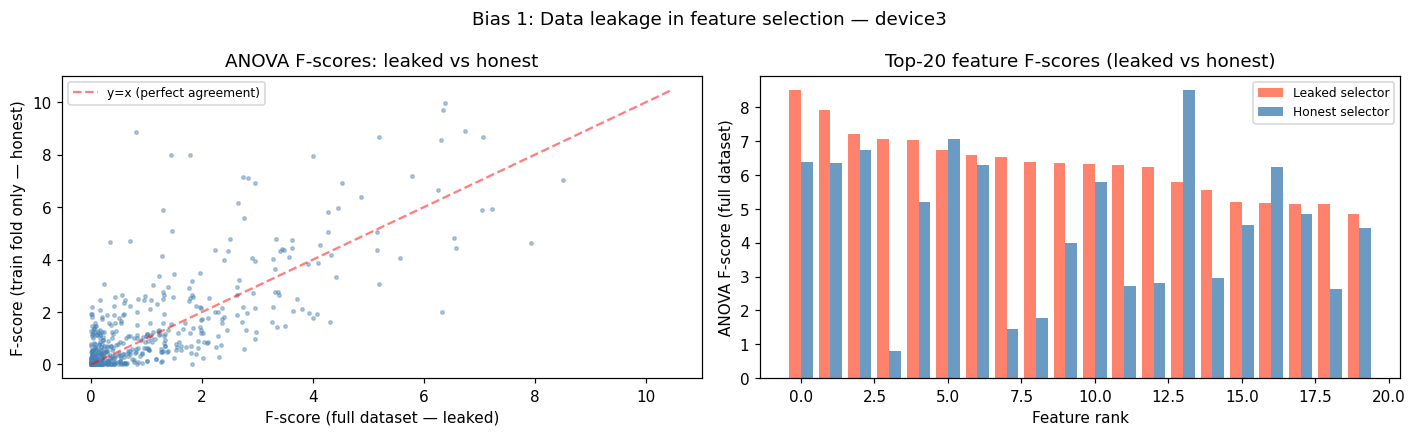

In [5]:
# Bias 1 demonstration: leaked vs honest feature selection
trial_info    = TRIALS_INFO[TRIALS_TO_RUN[0]]
target_device = trial_info['authorized'][0]

X_auth, y_auth, X_rogue, y_rogue = build_binary_dataset(
    X, y, device_id_mapping,
    trial_info['authorized'], target_device, trial_info['rogue']
)

K_DEMO = 20   # show top-20 features

# Leaked: fitted on full X_auth
sel_leaked = SelectKBest(f_classif, k=K_DEMO).fit(X_auth, y_auth)
feats_leaked = set(sel_leaked.get_support(indices=True))

# Honest: fitted only on training fold of the FIRST fold
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
train_idx, test_idx = next(skf.split(X_auth, y_auth))
sel_honest = SelectKBest(f_classif, k=K_DEMO).fit(X_auth[train_idx], y_auth[train_idx])
feats_honest = set(sel_honest.get_support(indices=True))

overlap    = feats_leaked & feats_honest
only_leaked = feats_leaked - feats_honest
only_honest = feats_honest - feats_leaked

print(f'Device: {target_device}  |  k={K_DEMO} features')
print(f'  Features selected by BOTH selectors : {len(overlap)}')
print(f'  Features ONLY in leaked selector    : {len(only_leaked)}')
print(f'  Features ONLY in honest selector    : {len(only_honest)}')
print(f'  Overlap = {len(overlap)/K_DEMO*100:.0f}% — the leaked selector has privileged test-set knowledge')

# Compare F-scores on full vs train-only
f_full,  _ = f_classif(X_auth,           y_auth)
f_train, _ = f_classif(X_auth[train_idx], y_auth[train_idx])

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].scatter(f_full, f_train, s=5, alpha=0.4, color='steelblue')
lim = max(f_full.max(), f_train.max()) * 1.05
axes[0].plot([0, lim], [0, lim], 'r--', alpha=0.5, label='y=x (perfect agreement)')
axes[0].set_xlabel('F-score (full dataset — leaked)')
axes[0].set_ylabel('F-score (train fold only — honest)')
axes[0].set_title('ANOVA F-scores: leaked vs honest')
axes[0].legend(fontsize=8)

# Show top-K selected by each
ranks_leaked = np.argsort(-f_full)[:K_DEMO]
ranks_honest = np.argsort(-f_train)[:K_DEMO]
bar_labels   = [str(i) for i in range(K_DEMO)]
leaked_scores = f_full[ranks_leaked]
honest_scores = f_full[ranks_honest]   # evaluate honest selection using full F-score for fair comparison
x = np.arange(K_DEMO)
axes[1].bar(x - 0.2, leaked_scores, 0.4, label='Leaked selector', color='tomato',    alpha=0.8)
axes[1].bar(x + 0.2, honest_scores, 0.4, label='Honest selector', color='steelblue', alpha=0.8)
axes[1].set_title(f'Top-{K_DEMO} feature F-scores (leaked vs honest)')
axes[1].set_xlabel('Feature rank')
axes[1].set_ylabel('ANOVA F-score (full dataset)')
axes[1].legend(fontsize=8)

plt.suptitle(f'Bias 1: Data leakage in feature selection — {target_device}', fontsize=12)
plt.tight_layout()
plt.show()

### Bias 2 — Lucky-fold selection
### Bias 3 — k-sweep on test data

We record the result of **every** (k, fold) combination for one device (no early break)
and show what fraction of combinations pass the 0.95 threshold.
This reveals how easy it is to find a passing result by chance.

In [ ]:
# Full (k, fold) sweep for one device — records every result, no early break
# Limit k range for speed; the pattern is clear in the first 100 values.
print(f'Sweeping k=1..{K_SWEEP_MAX} × {N_SPLITS} folds for device {target_device}...')

auth_tvr_grid  = np.zeros((K_SWEEP_MAX, N_SPLITS))
rogue_tvr_grid = np.zeros((K_SWEEP_MAX, N_SPLITS))
pass_grid      = np.zeros((K_SWEEP_MAX, N_SPLITS), dtype=bool)

for ki, k in enumerate(range(1, K_SWEEP_MAX + 1)):
    # BIAS 1 still present here — selector fitted on full X_auth
    selector    = SelectKBest(f_classif, k=k)
    X_auth_sel  = selector.fit_transform(X_auth, y_auth)
    X_rogue_sel = X_rogue[:, selector.get_support(indices=True)]

    skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
    for fi, (train_idx, test_idx) in enumerate(skf.split(X_auth_sel, y_auth)):
        model = SVC(kernel='poly', C=1.0)
        model.fit(X_auth_sel[train_idx], y_auth[train_idx])

        a_tvr = compute_tvr(y_auth[test_idx], model.predict(X_auth_sel[test_idx]), 1)
        r_tvr = compute_tvr(y_rogue,          model.predict(X_rogue_sel),          0)

        auth_tvr_grid[ki, fi]  = a_tvr
        rogue_tvr_grid[ki, fi] = r_tvr
        pass_grid[ki, fi]      = (a_tvr >= 0.95) and ((1 - a_tvr) <= 0.05) and \
                                  (r_tvr >= 0.95) and ((1 - r_tvr) <= 0.05)

n_passing = pass_grid.sum()
total     = K_SWEEP_MAX * N_SPLITS
print(f'\nPassing (k,fold) combinations: {n_passing} / {total} = {n_passing/total*100:.1f}%')
print(f'First passing combination: ', end='')
found = False
for ki in range(K_SWEEP_MAX):
    for fi in range(N_SPLITS):
        if pass_grid[ki, fi]:
            print(f'k={ki+1}, fold={fi+1}')
            found = True
            break
    if found:
        break
if not found:
    print('none in this range')

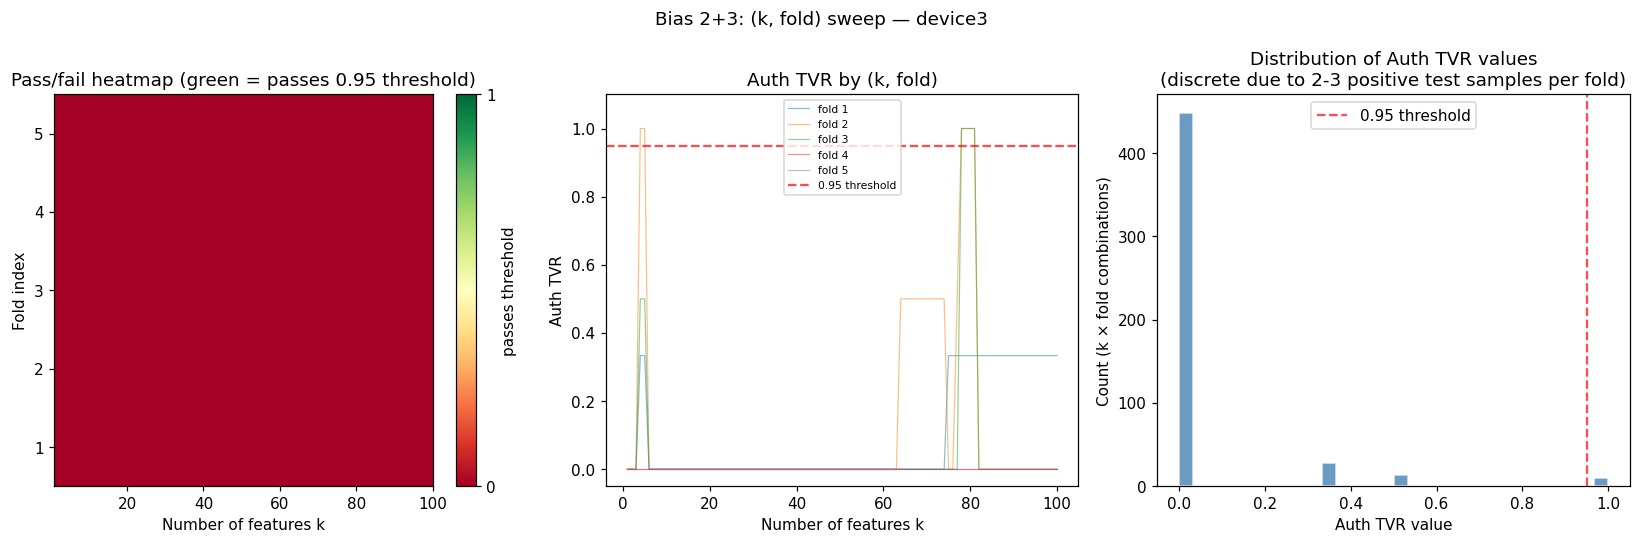


Note: 13 positive samples ÷ 5 folds ≈ 2 per test fold
→ Auth TVR can only take values: [0.0, 0.5, 1.0]


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

ks    = np.arange(1, K_SWEEP_MAX + 1)
folds = np.arange(1, N_SPLITS + 1)

# Heatmap: does each (k, fold) pass?
im = axes[0].imshow(pass_grid.T, aspect='auto', cmap='RdYlGn',
                    vmin=0, vmax=1, origin='lower',
                    extent=[1, K_SWEEP_MAX, 0.5, N_SPLITS + 0.5])
axes[0].set_xlabel('Number of features k')
axes[0].set_ylabel('Fold index')
axes[0].set_yticks(folds)
axes[0].set_title('Pass/fail heatmap (green = passes 0.95 threshold)')
plt.colorbar(im, ax=axes[0], ticks=[0, 1], label='passes threshold')

# Auth TVR per k (across folds)
for fi in range(N_SPLITS):
    axes[1].plot(ks, auth_tvr_grid[:, fi], alpha=0.5, linewidth=0.8,
                 label=f'fold {fi+1}')
axes[1].axhline(0.95, color='red', linestyle='--', alpha=0.7, label='0.95 threshold')
axes[1].set_xlabel('Number of features k')
axes[1].set_ylabel('Auth TVR')
axes[1].set_title('Auth TVR by (k, fold)')
axes[1].legend(fontsize=7)
axes[1].set_ylim(-0.05, 1.10)

# Note: with 2-3 positive test samples, Auth TVR can only be 0, 0.5, or 1.0
unique_vals = np.unique(auth_tvr_grid)
axes[2].hist(auth_tvr_grid.ravel(), bins=30, color='steelblue', alpha=0.8, edgecolor='white')
axes[2].set_xlabel('Auth TVR value')
axes[2].set_ylabel('Count (k × fold combinations)')
axes[2].set_title('Distribution of Auth TVR values\n(discrete due to 2-3 positive test samples per fold)')
axes[2].axvline(0.95, color='red', linestyle='--', alpha=0.7, label='0.95 threshold')
axes[2].legend()

plt.suptitle(f'Bias 2+3: (k, fold) sweep — {target_device}', fontsize=12)
plt.tight_layout()
plt.show()

n_pos_per_fold = int((y_auth == 1).sum() / N_SPLITS)
print(f'\nNote: {int((y_auth==1).sum())} positive samples ÷ {N_SPLITS} folds ≈ {n_pos_per_fold} per test fold')
print(f'→ Auth TVR can only take values: {sorted(set(np.round(i/n_pos_per_fold,2) for i in range(n_pos_per_fold+1)))}')

**Reading the heatmap**: device3 shows 0 passing (k, fold) combinations out of 500. This does not mean the original code produces no result for device3 — the original pipeline includes a **closeness-score fallback**: when no (k, fold) strictly meets all four threshold conditions (auth TVR ≥ 0.95, rogue TVR ≥ 0.95), it stores the combination that minimises the sum of absolute deviations from the target. Device3's reported auth TVR=1.000 in the original pipeline comes from this fallback, not from a strictly passing combination. The heatmap correctly shows that the threshold is never genuinely met — the 0.95 criterion is an aspirational target that device3 never reaches, yet the original code still reports it as a success.

## 4. Fix 1 — Feature selection inside the fold

**Change**: `SelectKBest` is now fitted only on the training split of each fold.
The same transform is applied to the test split and the rogue set.

Biases 2 and 3 (k-sweep + first-pass reporting) remain unchanged.

In [8]:
def run_fix1(X, y, device_id_mapping, trial_info, k_max=None):
    """Fix 1 only: feature selection inside the fold."""
    if k_max is None:
        k_max = X.shape[1]

    authorized = trial_info['authorized']
    rogue      = trial_info['rogue']
    results    = {}

    for target_device in authorized:
        X_auth, y_auth, X_rogue, y_rogue = build_binary_dataset(
            X, y, device_id_mapping, authorized, target_device, rogue
        )

        best_score  = float('inf')
        best_detail = None

        for k in range(1, k_max + 1):
            skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
            for train_idx, test_idx in skf.split(X_auth, y_auth):
                # ✓ FIX 1: selector fitted only on training fold
                selector    = SelectKBest(f_classif, k=k)
                X_tr        = selector.fit_transform(X_auth[train_idx], y_auth[train_idx])
                X_te        = selector.transform(X_auth[test_idx])
                X_rogue_sel = selector.transform(X_rogue)
                y_tr        = y_auth[train_idx]
                y_te        = y_auth[test_idx]

                model = SVC(kernel='poly', C=1.0)
                model.fit(X_tr, y_tr)

                auth_tvr  = compute_tvr(y_te,    model.predict(X_te),        1)
                auth_fvr  = 1.0 - auth_tvr
                rogue_tvr = compute_tvr(y_rogue, model.predict(X_rogue_sel), 0)
                rogue_fvr = 1.0 - rogue_tvr

                # BIAS 2+3 still present
                if auth_tvr >= 0.95 and auth_fvr <= 0.05 and rogue_tvr >= 0.95 and rogue_fvr <= 0.05:
                    results[target_device] = {
                        'auth_tvr': auth_tvr, 'rogue_tvr': rogue_tvr,
                        'auth_fvr': auth_fvr, 'k': k
                    }
                    break

                score = abs(auth_tvr - 0.95) + abs(auth_fvr - 0.05) + \
                        abs(rogue_tvr - 0.95) + abs(rogue_fvr - 0.05)
                if score < best_score:
                    best_score  = score
                    best_detail = {
                        'auth_tvr': auth_tvr, 'rogue_tvr': rogue_tvr,
                        'auth_fvr': auth_fvr, 'k': k
                    }

            if target_device in results:
                break

        if target_device not in results and best_detail is not None:
            results[target_device] = best_detail

    return results


print('Fix 1 pipeline defined.')

Fix 1 pipeline defined.


In [9]:
fix1_results = {}
for trial_name in TRIALS_TO_RUN:
    print(f'\nRunning Fix-1 pipeline on {trial_name}...')
    res = run_fix1(X, y, device_id_mapping, TRIALS_INFO[trial_name])
    fix1_results[trial_name] = res
    print_results(res, f'FIX 1 (selection inside fold) — {trial_name}')


Running Fix-1 pipeline on trial_1...

────────────────────────────────────────────────────────
  FIX 1 (selection inside fold) — trial_1
────────────────────────────────────────────────────────
  Device         Auth TVR  Rogue TVR      ADR
  ────────────────────────────────────────────────
  device3           0.500      0.960    0.730
  device2           0.500      0.950    0.725
  device12          1.000      0.930    0.965
  device9           0.500      0.950    0.725
  ────────────────────────────────────────────────
  AVERAGE           0.625      0.948    0.786
────────────────────────────────────────────────────────


## 5. Fix 1+2 — Average all folds, remove threshold break

**Additional change**: all 5 folds run for every k value. Results are averaged across folds. No early break on threshold — the best k is the one with highest average ADR.

This eliminates **Bias 2** (lucky-fold selection). **Bias 3 remains**: the best k is still chosen by the average test-set ADR across folds. Selecting a hyperparameter by the metric it is evaluated on is a form of test-set model selection — more stable than the single-fold version, but still optimistic. Fix 3 removes this by fixing k a priori.

In [10]:
def run_fix1_2(X, y, device_id_mapping, trial_info, k_max=None):
    """Fix 1+2: selection inside fold + average all folds."""
    if k_max is None:
        k_max = X.shape[1]

    authorized = trial_info['authorized']
    rogue      = trial_info['rogue']
    results    = {}

    for target_device in authorized:
        X_auth, y_auth, X_rogue, y_rogue = build_binary_dataset(
            X, y, device_id_mapping, authorized, target_device, rogue
        )

        best_adr = -1.0
        best_detail = None

        for k in range(1, k_max + 1):
            fold_auth, fold_rogue = [], []

            skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
            for train_idx, test_idx in skf.split(X_auth, y_auth):
                # ✓ FIX 1: selection inside fold
                selector    = SelectKBest(f_classif, k=k)
                X_tr        = selector.fit_transform(X_auth[train_idx], y_auth[train_idx])
                X_te        = selector.transform(X_auth[test_idx])
                X_rogue_sel = selector.transform(X_rogue)

                model = SVC(kernel='poly', C=1.0)
                model.fit(X_tr, y_auth[train_idx])

                fold_auth.append(compute_tvr(y_auth[test_idx], model.predict(X_te),        1))
                fold_rogue.append(compute_tvr(y_rogue,          model.predict(X_rogue_sel), 0))

            # ✓ FIX 2: average all folds, no break
            mean_auth  = float(np.mean(fold_auth))
            mean_rogue = float(np.mean(fold_rogue))
            mean_adr   = (mean_auth + mean_rogue) / 2

            if mean_adr > best_adr:
                best_adr    = mean_adr
                best_detail = {
                    'auth_tvr': mean_auth, 'rogue_tvr': mean_rogue,
                    'auth_fvr': 1 - mean_auth, 'k': k
                }

        results[target_device] = best_detail

    return results


print('Fix 1+2 pipeline defined.')

Fix 1+2 pipeline defined.


In [11]:
fix12_results = {}
for trial_name in TRIALS_TO_RUN:
    print(f'\nRunning Fix-1+2 pipeline on {trial_name} (full k-sweep, no early break)...')
    res = run_fix1_2(X, y, device_id_mapping, TRIALS_INFO[trial_name])
    fix12_results[trial_name] = res
    print_results(res, f'FIX 1+2 (avg all folds) — {trial_name}')


Running Fix-1+2 pipeline on trial_1 (full k-sweep, no early break)...

────────────────────────────────────────────────────────
  FIX 1+2 (avg all folds) — trial_1
────────────────────────────────────────────────────────
  Device         Auth TVR  Rogue TVR      ADR
  ────────────────────────────────────────────────
  device3           0.200      0.930    0.565
  device2           0.167      0.910    0.538
  device12          0.200      0.952    0.576
  device9           0.133      0.940    0.537
  ────────────────────────────────────────────────
  AVERAGE           0.175      0.933    0.554
────────────────────────────────────────────────────────


## 6. Fix 1+2+3 — Fixed k, no sweep

**Additional change**: k is fixed to `K_FIXED` (set at the top of the notebook, default 50).
No sweep means no test-set model selection — k is chosen a priori.

This is the honest baseline: selection inside fold, all folds averaged, single k.

In [12]:
def run_fix1_2_3(X, y, device_id_mapping, trial_info, k=None, groups=None):
    """Fix 1+2+3: selection inside fold + average all folds + fixed k.

    groups : optional int array of shape (len(y),) assigning each sample a
             transient group ID. When provided, GroupKFold is used so all
             windows of one transient stay in the same fold — preventing
             window-level leakage in the windowed dataset.
    """
    if k is None:
        k = K_FIXED

    authorized  = trial_info['authorized']
    rogue       = trial_info['rogue']
    auth_labels = [device_id_mapping[d] for d in authorized]
    results     = {}

    for target_device in authorized:
        X_auth, y_auth, X_rogue, y_rogue = build_binary_dataset(
            X, y, device_id_mapping, authorized, target_device, rogue
        )

        fold_auth, fold_rogue = [], []

        if groups is not None:
            # Filter group IDs to the authorized subset (same mask as build_binary_dataset)
            auth_mask   = np.isin(y, auth_labels)
            groups_auth = groups[auth_mask]
            kf        = GroupKFold(n_splits=N_SPLITS)
            fold_iter = kf.split(X_auth, y_auth, groups=groups_auth)
        else:
            skf       = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
            fold_iter = skf.split(X_auth, y_auth)

        for train_idx, test_idx in fold_iter:
            # ✓ FIX 1: selection inside fold
            selector    = SelectKBest(f_classif, k=k)
            X_tr        = selector.fit_transform(X_auth[train_idx], y_auth[train_idx])
            X_te        = selector.transform(X_auth[test_idx])
            X_rogue_sel = selector.transform(X_rogue)

            model = SVC(kernel='poly', C=1.0)
            model.fit(X_tr, y_auth[train_idx])

            fold_auth.append(compute_tvr(y_auth[test_idx], model.predict(X_te),        1))
            fold_rogue.append(compute_tvr(y_rogue,          model.predict(X_rogue_sel), 0))

        # ✓ FIX 2: average all folds
        # ✓ FIX 3: no k-sweep, fixed k used above
        results[target_device] = {
            'auth_tvr':  float(np.mean(fold_auth)),
            'rogue_tvr': float(np.mean(fold_rogue)),
            'auth_fvr':  1 - float(np.mean(fold_auth)),
            'k':         k
        }

    return results


print('Fix 1+2+3 pipeline defined.')

Fix 1+2+3 pipeline defined.


In [13]:
fix123_results = {}
for trial_name in TRIALS_TO_RUN:
    print(f'\nRunning Fix-1+2+3 pipeline on {trial_name} (k={K_FIXED}, no sweep)...')
    res = run_fix1_2_3(X, y, device_id_mapping, TRIALS_INFO[trial_name])
    fix123_results[trial_name] = res
    print_results(res, f'FIX 1+2+3 (honest baseline, k={K_FIXED}) — {trial_name}')


Running Fix-1+2+3 pipeline on trial_1 (k=50, no sweep)...

────────────────────────────────────────────────────────
  FIX 1+2+3 (honest baseline, k=50) — trial_1
────────────────────────────────────────────────────────
  Device         Auth TVR  Rogue TVR      ADR
  ────────────────────────────────────────────────
  device3           0.000      0.956    0.478
  device2           0.000      0.898    0.449
  device12          0.000      0.908    0.454
  device9           0.000      0.898    0.449
  ────────────────────────────────────────────────
  AVERAGE           0.000      0.915    0.458
────────────────────────────────────────────────────────


## 6b. Fix 1+2+3 + Class-weight correction

The honest SVM (Fix 1+2+3) produces Auth TVR = 0.0: the classifier predicts all-reject because `SVC(kernel='poly')` defaults to `class_weight=None`, and the 1:3 positive:negative ratio makes the decision boundary collapse to the majority class.

This is **not one of the three evaluation biases** — the original code has the same imbalance. It is however an additional methodological flaw that makes the direct comparison with DL models unfair, since the DL pipeline uses inverse-frequency class weights via weighted cross-entropy loss.

This section adds `class_weight='balanced'` to the corrected SVM to produce a valid honest baseline. The three bias-correction fixes from Section 6 are preserved unchanged.

In [14]:
def run_fix1_2_3_balanced(X, y, device_id_mapping, trial_info, k=None, groups=None):
    """Fix 1+2+3 + class_weight='balanced'.

    Identical to run_fix1_2_3 except the SVC uses inverse-frequency class weights,
    compensating for the 1:3 positive:negative imbalance. This is an additional
    correction on top of the three evaluation biases — it makes the SVM comparison
    with DL models (which use weighted cross-entropy loss) methodologically fair.

    The original pipeline does NOT use class_weight='balanced'; that omission is
    part of why Auth TVR collapses to 0.0 in the honest fixed pipeline.
    """
    if k is None:
        k = K_FIXED

    authorized  = trial_info['authorized']
    rogue       = trial_info['rogue']
    auth_labels = [device_id_mapping[d] for d in authorized]
    results     = {}

    for target_device in authorized:
        X_auth, y_auth, X_rogue, y_rogue = build_binary_dataset(
            X, y, device_id_mapping, authorized, target_device, rogue
        )

        fold_auth, fold_rogue = [], []

        if groups is not None:
            auth_mask   = np.isin(y, auth_labels)
            groups_auth = groups[auth_mask]
            kf        = GroupKFold(n_splits=N_SPLITS)
            fold_iter = kf.split(X_auth, y_auth, groups=groups_auth)
        else:
            skf       = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
            fold_iter = skf.split(X_auth, y_auth)

        for train_idx, test_idx in fold_iter:
            selector    = SelectKBest(f_classif, k=k)
            X_tr        = selector.fit_transform(X_auth[train_idx], y_auth[train_idx])
            X_te        = selector.transform(X_auth[test_idx])
            X_rogue_sel = selector.transform(X_rogue)

            # ✓ ADDITIONAL FIX: balanced weights correct the 1:3 class imbalance
            model = SVC(kernel='poly', C=1.0, class_weight='balanced')
            model.fit(X_tr, y_auth[train_idx])

            fold_auth.append(compute_tvr(y_auth[test_idx], model.predict(X_te),        1))
            fold_rogue.append(compute_tvr(y_rogue,          model.predict(X_rogue_sel), 0))

        results[target_device] = {
            'auth_tvr':  float(np.mean(fold_auth)),
            'rogue_tvr': float(np.mean(fold_rogue)),
            'auth_fvr':  1 - float(np.mean(fold_auth)),
            'k':         k
        }

    return results


print('Fix 1+2+3 + balanced weights pipeline defined.')

Fix 1+2+3 + balanced weights pipeline defined.


In [15]:
balanced_results = {}
for trial_name in TRIALS_TO_RUN:
    print(f'\nRunning Fix-1+2+3 + balanced weights on {trial_name} (k={K_FIXED})...')
    res = run_fix1_2_3_balanced(X, y, device_id_mapping, TRIALS_INFO[trial_name])
    balanced_results[trial_name] = res
    print_results(res, f'FIX 1+2+3 + balanced weights (k={K_FIXED}) — {trial_name}')

for trial_name in TRIALS_TO_RUN:
    s_unbal = summarise(fix123_results[trial_name])
    s_bal   = summarise(balanced_results[trial_name])
    print(f'\n  {trial_name} — impact of class_weight="balanced":')
    print(f'    Auth TVR:  {s_unbal["mean_auth_tvr"]:.3f} → {s_bal["mean_auth_tvr"]:.3f}')
    print(f'    Rogue TVR: {s_unbal["mean_rogue_tvr"]:.3f} → {s_bal["mean_rogue_tvr"]:.3f}')
    print(f'    ADR:       {s_unbal["mean_adr"]:.3f} → {s_bal["mean_adr"]:.3f}')


Running Fix-1+2+3 + balanced weights on trial_1 (k=50)...

────────────────────────────────────────────────────────
  FIX 1+2+3 + balanced weights (k=50) — trial_1
────────────────────────────────────────────────────────
  Device         Auth TVR  Rogue TVR      ADR
  ────────────────────────────────────────────────
  device3           0.167      0.618    0.392
  device2           0.167      0.682    0.424
  device12          0.000      0.880    0.440
  device9           0.267      0.580    0.423
  ────────────────────────────────────────────────
  AVERAGE           0.150      0.690    0.420
────────────────────────────────────────────────────────

  trial_1 — impact of class_weight="balanced":
    Auth TVR:  0.000 → 0.150
    Rogue TVR: 0.915 → 0.690
    ADR:       0.458 → 0.420


## 7. Comparison

Side-by-side comparison of all four pipeline variants showing the progressive
ADR deflation as each bias is removed.

In [16]:
pipeline_labels = [
    'Original\n(all biases)',
    'Fix 1\n(no leakage)',
    'Fix 1+2\n(avg folds)',
    f'Fix 1+2+3\n(k={K_FIXED}, honest)',
]

for trial_name in TRIALS_TO_RUN:
    all_variants = [
        original_results[trial_name],
        fix1_results[trial_name],
        fix12_results[trial_name],
        fix123_results[trial_name],
    ]

    summaries = [summarise(r) for r in all_variants]

    print(f'\n{"="*68}')
    print(f'  Comparison — {trial_name}')
    print(f'{"="*68}')
    print(f'  {"Pipeline":<25} {"Auth TVR":>10} {"Rogue TVR":>10} {"ADR":>8}')
    print(f'  {"─"*56}')
    for label, s in zip(pipeline_labels, summaries):
        tag = label.replace('\n', ' ')
        print(f'  {tag:<25} {s["mean_auth_tvr"]:>10.3f} {s["mean_rogue_tvr"]:>10.3f} {s["mean_adr"]:>8.3f}')
    print(f'{"="*68}')


  Comparison — trial_1
  Pipeline                    Auth TVR  Rogue TVR      ADR
  ────────────────────────────────────────────────────────
  Original (all biases)          1.000      0.945    0.973
  Fix 1 (no leakage)             0.625      0.948    0.786
  Fix 1+2 (avg folds)            0.175      0.933    0.554
  Fix 1+2+3 (k=50, honest)       0.000      0.915    0.458


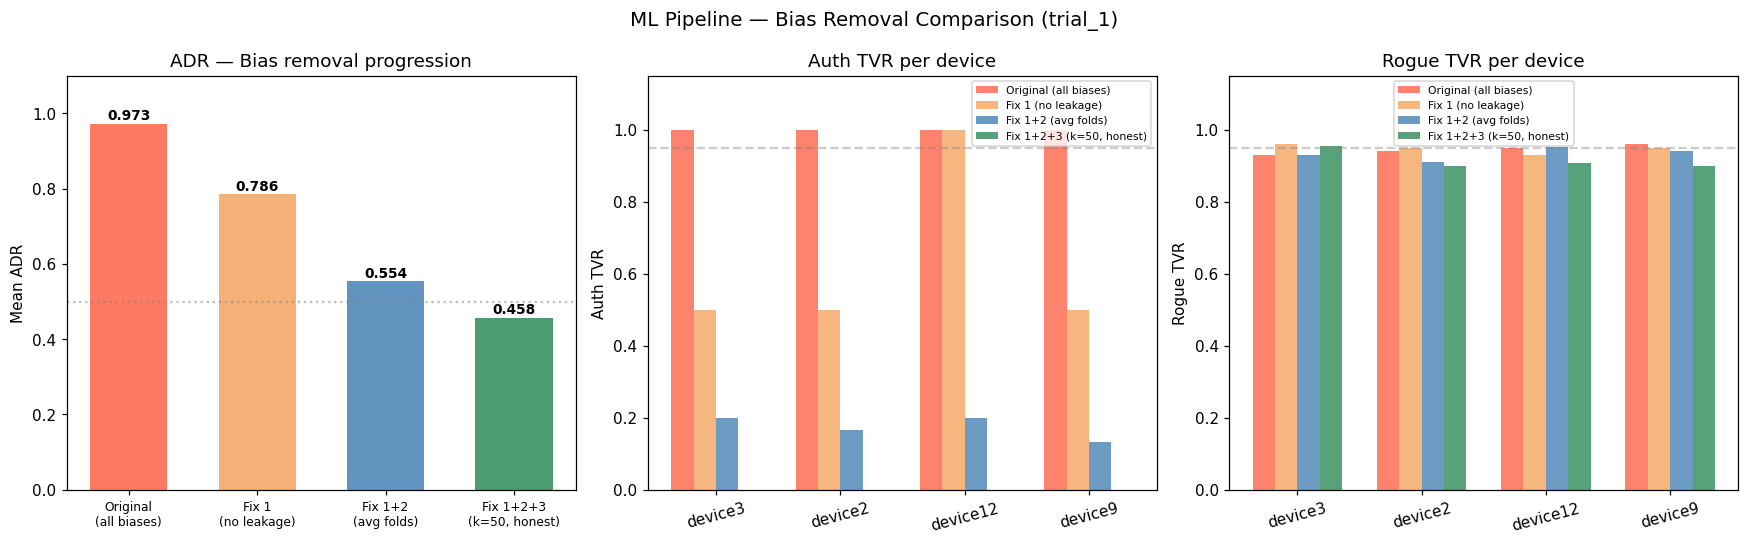

In [17]:
colors = ['tomato', 'sandybrown', 'steelblue', 'seagreen']

for trial_name in TRIALS_TO_RUN:
    all_variants = [
        original_results[trial_name],
        fix1_results[trial_name],
        fix12_results[trial_name],
        fix123_results[trial_name],
    ]
    summaries = [summarise(r) for r in all_variants]
    devices   = list(all_variants[0].keys())

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    # Plot 1: mean ADR progression
    adrs = [s['mean_adr'] for s in summaries]
    bars = axes[0].bar(range(4), adrs, color=colors, alpha=0.85, width=0.6)
    axes[0].set_xticks(range(4))
    axes[0].set_xticklabels(pipeline_labels, fontsize=8)
    axes[0].set_ylim(0, 1.1)
    axes[0].set_ylabel('Mean ADR')
    axes[0].set_title('ADR — Bias removal progression')
    axes[0].axhline(0.5, color='gray', linestyle=':', alpha=0.5, label='random')
    for bar, v in zip(bars, adrs):
        axes[0].text(bar.get_x() + bar.get_width()/2, v + 0.01,
                     f'{v:.3f}', ha='center', fontsize=9, fontweight='bold')

    # Plot 2: per-device Auth TVR across pipelines
    x = np.arange(len(devices))
    width = 0.18
    for i, (variant, label, color) in enumerate(zip(all_variants, pipeline_labels, colors)):
        vals = [variant[d]['auth_tvr'] for d in devices]
        axes[1].bar(x + (i - 1.5) * width, vals, width, label=label.replace('\n', ' '),
                    color=color, alpha=0.8)
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(devices, rotation=15)
    axes[1].set_ylim(0, 1.15)
    axes[1].set_ylabel('Auth TVR')
    axes[1].set_title('Auth TVR per device')
    axes[1].axhline(0.95, color='gray', linestyle='--', alpha=0.4)
    axes[1].legend(fontsize=7)

    # Plot 3: per-device Rogue TVR across pipelines
    for i, (variant, label, color) in enumerate(zip(all_variants, pipeline_labels, colors)):
        vals = [variant[d]['rogue_tvr'] for d in devices]
        axes[2].bar(x + (i - 1.5) * width, vals, width, label=label.replace('\n', ' '),
                    color=color, alpha=0.8)
    axes[2].set_xticks(x)
    axes[2].set_xticklabels(devices, rotation=15)
    axes[2].set_ylim(0, 1.15)
    axes[2].set_ylabel('Rogue TVR')
    axes[2].set_title('Rogue TVR per device')
    axes[2].axhline(0.95, color='gray', linestyle='--', alpha=0.4)
    axes[2].legend(fontsize=7)

    plt.suptitle(f'ML Pipeline — Bias Removal Comparison ({trial_name})', fontsize=13)
    plt.tight_layout()
    plt.show()

## 8. Extra — Corrected pipeline on windowed data

This section is **not a fix** to the original methodology — it tests the same corrected pipeline
(Fix 1+2+3) on windowed data (10 overlapping windows per transient, ~130 samples per device
instead of 13).

Two questions:
1. Does more data improve the corrected SVM?
2. How does the corrected SVM compare with the DL pipeline (from notebook 01) on the same data?

**Interpretation note**: the original work never used windowing. Higher SVM performance here
reflects a more favourable sample/feature ratio (130 vs 13 samples per device), not a better
model. This motivates the DL pipeline which is designed around windowing from the start.

In [ ]:
import h5py
from binary_pla.config import FV_WINDOWED_PATH

print(f'Loading windowed data from: {FV_WINDOWED_PATH}')
with h5py.File(FV_WINDOWED_PATH, 'r') as f:
    X_win = f['data'][:].astype(np.float32)
    y_win = f['labels'][:].astype(np.int64)

print(f'X_win shape: {X_win.shape}')
print(f'Samples per device:')
for label in np.unique(y_win):
    print(f'  label {label}: {(y_win == label).sum()} samples')

# Compute transient group IDs so all windows of one transient land in the same CV fold.
groups_win = np.zeros(len(y_win), dtype=np.int64)
for i, lbl in enumerate(np.unique(y_win)):
    dev_pos = np.where(y_win == lbl)[0]
    groups_win[dev_pos] = i * 10_000 + (np.arange(len(dev_pos)) // N_WINDOWS)

n_groups = len(np.unique(groups_win))
print(f'\nTransient groups computed: {n_groups} unique groups '
      f'({n_groups // len(np.unique(y_win))} transients/device on average)')
print(f'Label mapping (same as original): {device_id_mapping}')

In [19]:
windowed_results = {}
for trial_name in TRIALS_TO_RUN:
    print(f'\nRunning corrected pipeline (Fix 1+2+3) on WINDOWED data — {trial_name}...')
    print(f'  Using GroupKFold: windows from the same transient stay in the same fold.')
    res = run_fix1_2_3_balanced(X_win, y_win, device_id_mapping, TRIALS_INFO[trial_name], groups=groups_win)
    windowed_results[trial_name] = res
    print_results(res, f'CORRECTED (k={K_FIXED}, group-aware CV) — windowed — {trial_name}')


Running corrected pipeline (Fix 1+2+3) on WINDOWED data — trial_1...
  Using GroupKFold: windows from the same transient stay in the same fold.

────────────────────────────────────────────────────────
  CORRECTED (k=50, group-aware CV) — windowed — trial_1
────────────────────────────────────────────────────────
  Device         Auth TVR  Rogue TVR      ADR
  ────────────────────────────────────────────────
  device3           0.780      0.310    0.545
  device2           0.462      0.718    0.590
  device12          0.460      0.785    0.622
  device9           0.883      0.198    0.540
  ────────────────────────────────────────────────
  AVERAGE           0.646      0.502    0.574
────────────────────────────────────────────────────────


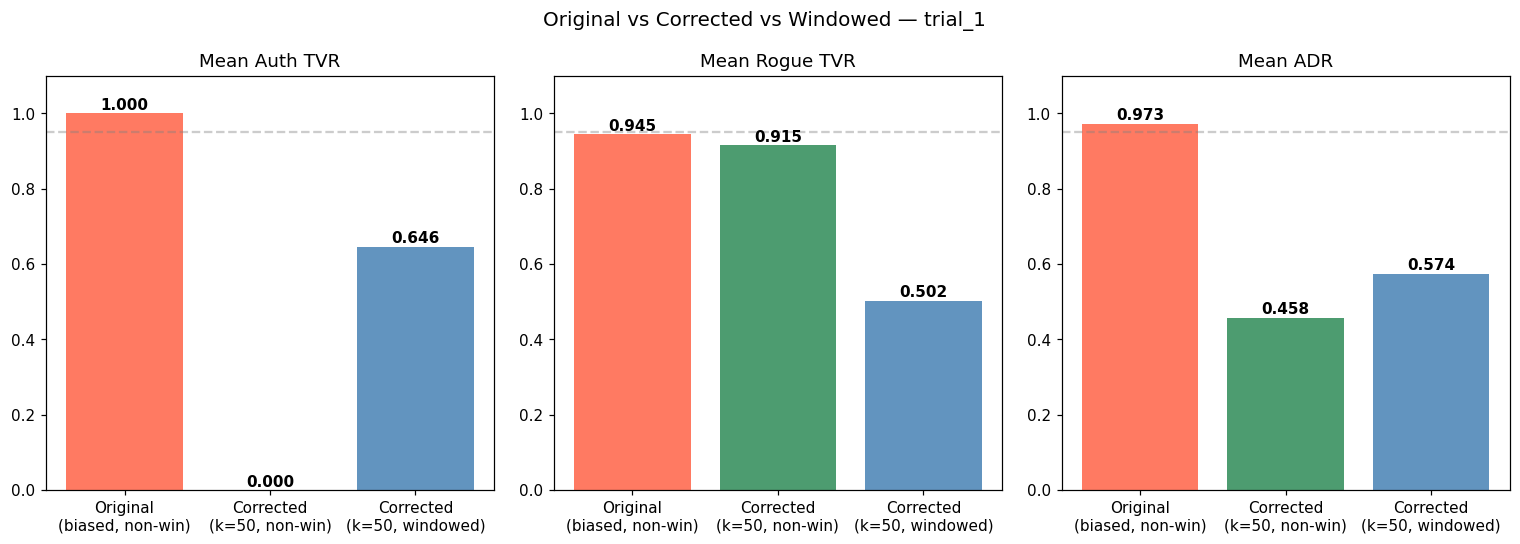


trial_1 — summary:
  Original (biased, non-windowed): ADR = 0.973
  Corrected (k=50, non-windowed): ADR = 0.458
  Corrected (k=50, windowed):     ADR = 0.574
  → Bias inflation: 0.515 ADR points
  → Windowing gain on corrected SVM: 0.117 ADR points


In [20]:
for trial_name in TRIALS_TO_RUN:
    s_orig     = summarise(original_results[trial_name])
    s_corrected = summarise(fix123_results[trial_name])
    s_windowed  = summarise(windowed_results[trial_name])

    fig, axes = plt.subplots(1, 3, figsize=(14, 5))

    labels_cmp = ['Original\n(biased, non-win)', f'Corrected\n(k={K_FIXED}, non-win)', f'Corrected\n(k={K_FIXED}, windowed)']
    colors_cmp = ['tomato', 'seagreen', 'steelblue']

    for ax, metric, title in [
        (axes[0], 'mean_auth_tvr',  'Mean Auth TVR'),
        (axes[1], 'mean_rogue_tvr', 'Mean Rogue TVR'),
        (axes[2], 'mean_adr',       'Mean ADR'),
    ]:
        vals = [s_orig[metric], s_corrected[metric], s_windowed[metric]]
        bars = ax.bar(labels_cmp, vals, color=colors_cmp, alpha=0.85)
        ax.set_ylim(0, 1.1)
        ax.set_title(title)
        ax.axhline(0.95, color='gray', linestyle='--', alpha=0.4, label='0.95')
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width()/2, v + 0.01,
                    f'{v:.3f}', ha='center', fontsize=10, fontweight='bold')

    plt.suptitle(f'Original vs Corrected vs Windowed — {trial_name}', fontsize=13)
    plt.tight_layout()
    plt.show()

    print(f'\n{trial_name} — summary:')
    print(f'  Original (biased, non-windowed): ADR = {s_orig["mean_adr"]:.3f}')
    print(f'  Corrected (k={K_FIXED}, non-windowed): ADR = {s_corrected["mean_adr"]:.3f}')
    print(f'  Corrected (k={K_FIXED}, windowed):     ADR = {s_windowed["mean_adr"]:.3f}')
    print(f'  → Bias inflation: {s_orig["mean_adr"] - s_corrected["mean_adr"]:.3f} ADR points')
    print(f'  → Windowing gain on corrected SVM: {s_windowed["mean_adr"] - s_corrected["mean_adr"]:.3f} ADR points')

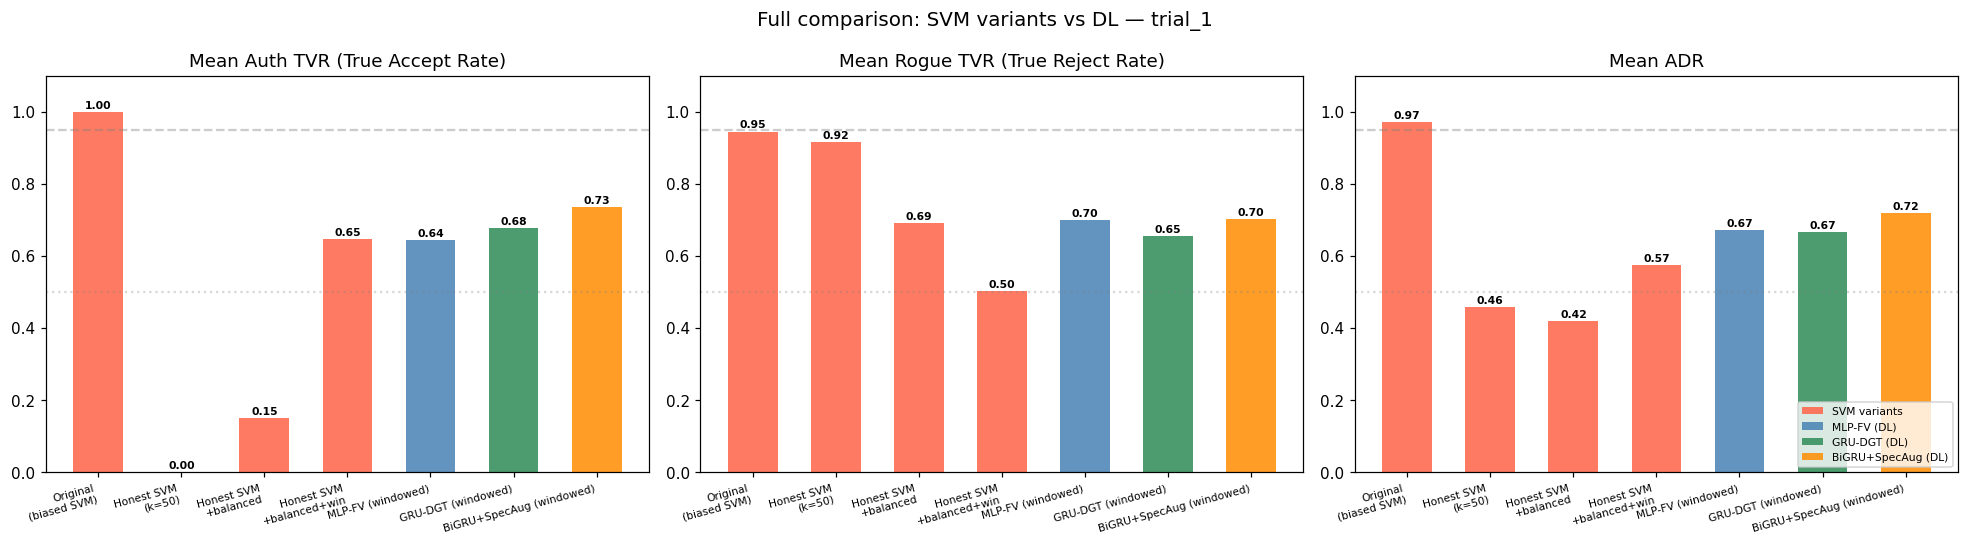


Model                           Auth TVR  Rogue TVR     ADR
────────────────────────────────────────────────────────────
Original (biased SVM)              1.000      0.945   0.973
Honest SVM (k=50)                  0.000      0.915   0.458
Honest SVM +balanced               0.150      0.690   0.420
Honest SVM +balanced+win           0.646      0.502   0.574
MLP-FV (windowed)                  0.644      0.699   0.671
GRU-DGT (windowed)                 0.677      0.654   0.665
BiGRU+SpecAug (windowed)           0.735      0.703   0.719


In [21]:
# ── DL comparison (results from notebook 01, honest transient-aware split) ────
# Update these values after re-running notebook 01 with the fixed data loader.
DL_RESULTS = {
    'MLP-FV (windowed)':       {'auth_tvr': 0.644, 'rogue_tvr': 0.699, 'adr': 0.671},
    'GRU-DGT (windowed)':      {'auth_tvr': 0.677, 'rogue_tvr': 0.654, 'adr': 0.665},
    'BiGRU+SpecAug (windowed)':{'auth_tvr': 0.735, 'rogue_tvr': 0.703, 'adr': 0.719},
}

for trial_name in TRIALS_TO_RUN:
    s_orig     = summarise(original_results[trial_name])
    s_corrected = summarise(fix123_results[trial_name])
    s_balanced  = summarise(balanced_results[trial_name])
    s_windowed  = summarise(windowed_results[trial_name])

    # Build labels and values including DL entries
    labels_full  = [
        'Original\n(biased SVM)',
        f'Honest SVM\n(k={K_FIXED})',
        f'Honest SVM\n+balanced',
        f'Honest SVM\n+balanced+win',
    ] + list(DL_RESULTS.keys())

    auth_vals  = [s_orig['mean_auth_tvr'],  s_corrected['mean_auth_tvr'],
                  s_balanced['mean_auth_tvr'], s_windowed['mean_auth_tvr']] + \
                 [v['auth_tvr']  for v in DL_RESULTS.values()]
    rogue_vals = [s_orig['mean_rogue_tvr'], s_corrected['mean_rogue_tvr'],
                  s_balanced['mean_rogue_tvr'], s_windowed['mean_rogue_tvr']] + \
                 [v['rogue_tvr'] for v in DL_RESULTS.values()]
    adr_vals   = [s_orig['mean_adr'],       s_corrected['mean_adr'],
                  s_balanced['mean_adr'],     s_windowed['mean_adr']] + \
                 [v['adr']       for v in DL_RESULTS.values()]

    colors_full = ['tomato'] * 4 + ['steelblue', 'seagreen', 'darkorange']

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    x = np.arange(len(labels_full))

    for ax, vals, title in [
        (axes[0], auth_vals,  'Mean Auth TVR (True Accept Rate)'),
        (axes[1], rogue_vals, 'Mean Rogue TVR (True Reject Rate)'),
        (axes[2], adr_vals,   'Mean ADR'),
    ]:
        bars = ax.bar(x, vals, color=colors_full, alpha=0.85, width=0.6)
        ax.set_xticks(x)
        ax.set_xticklabels(labels_full, fontsize=7, rotation=15, ha='right')
        ax.set_ylim(0, 1.1)
        ax.set_title(title)
        ax.axhline(0.95, color='gray', linestyle='--', alpha=0.4)
        ax.axhline(0.5,  color='gray', linestyle=':',  alpha=0.3, label='random')
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width()/2, v + 0.01,
                    f'{v:.2f}', ha='center', fontsize=7, fontweight='bold')

    # Legend: red=SVM variants, coloured=DL models
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='tomato',     alpha=0.85, label='SVM variants'),
        Patch(facecolor='steelblue',  alpha=0.85, label='MLP-FV (DL)'),
        Patch(facecolor='seagreen',   alpha=0.85, label='GRU-DGT (DL)'),
        Patch(facecolor='darkorange', alpha=0.85, label='BiGRU+SpecAug (DL)'),
    ]
    axes[2].legend(handles=legend_elements, fontsize=7, loc='lower right')

    plt.suptitle(f'Full comparison: SVM variants vs DL — {trial_name}', fontsize=13)
    plt.tight_layout()
    plt.show()

    print(f'\n{"Model":<30} {"Auth TVR":>9} {"Rogue TVR":>10} {"ADR":>7}')
    print('─' * 60)
    for lbl, a, r, d in zip(labels_full, auth_vals, rogue_vals, adr_vals):
        tag = lbl.replace('\n', ' ')
        print(f'{tag:<30} {a:>9.3f} {r:>10.3f} {d:>7.3f}')

## 9. Save results

In [ ]:
from binary_pla.config import NB01_ID
from binary_pla.results_io import save_results

def _build_variant(results_dict, trial):
    """Flatten per-device results for one pipeline variant into a JSON-ready dict."""
    trial_res = results_dict[trial]
    out = {}
    for dev, r in trial_res.items():
        out[dev] = {
            "auth_tvr":  float(r["auth_tvr"]),
            "rogue_tvr": float(r["rogue_tvr"]),
            "adr":       float((r["auth_tvr"] + r["rogue_tvr"]) / 2),
        }
        if "k" in r:
            out[dev]["k"] = int(r["k"])
    s = summarise(trial_res)
    out["_summary"] = {k: float(v) for k, v in s.items()}
    return out

for trial in TRIALS_TO_RUN:
    results_payload = {
        "original":          _build_variant(original_results,   trial),
        "fix1":              _build_variant(fix1_results,        trial),
        "fix1_2":            _build_variant(fix12_results,       trial),
        "fix1_2_3":          _build_variant(fix123_results,      trial),
        "fix1_2_3_balanced": _build_variant(balanced_results,    trial),
        "windowed_balanced": _build_variant(windowed_results,    trial),
    }
    save_results(
        NB01_ID, trial, results_payload,
        extra_meta={
            "k_fixed":      K_FIXED,
            "n_splits":     N_SPLITS,
            "random_state": RANDOM_STATE,
            "trials_run":   TRIALS_TO_RUN,
        },
    )